> **해당 데이터는 내부 보안 규정을 준수하여 로컬 환경에서 수작업으로 레이블링되었음**

> 각 셀은 Colab에서 순차 실행되었으며 일부는 재실행 방지를 위해 주석 처리됨

> Pretrained Model:
> - Ultralytics YOLO26-Large (`yolo26l.pt`) — 최종 제출 모델 (fine-tuning)
> - Grounding DINO (`IDEA-Research/grounding-dino-base`) — 라벨링 보조용, 최종 모델에는 미포함

① Grounding DINO를 이용해서 상자 DETECT 후 BBOX auto-labelling

② Label Studio 수작업 수정

    - 오탐 제거
    - 누락 bbox 추가
    - 빈 프레임 확인

③ YOLO26 ( Box Detection ) fine-tuning

    - v5 : Grounding Dino가 탐지하지 못한 Box에 대해서만 bbox 수작업 labelling이 된 data로 학습된 Yolo 26 large model
        → Grounding DINO의 일반화 성능을 유지하는 방향으로 학습되어, **최종 제출 파이프라인의 Box Detection 모델**로 사용됨

    - v6 : v5에서 Grounding Dino가 오탐지한 bbox에 대해서 수정이 적용된 수작업 labelling이 된 data로 학습된 Yolo 26 large model
        → 오탐이 줄어들어, **Box Regressor 학습용 데이터셋(트래킹/크롭) 생성 단계**에서 사용됨


> 이 노트북을 데이터셋 버전만 바꿔서 두 번 실행함

# Grounding DINO를 활용해서 YOLO26 ( Box Detection ) 모델 학습용 DATA SET 만들기

In [1]:
# ==============================================================================
# YOLO 학습 데이터 생성 — Grounding DINO auto-labeling
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, glob, shutil
from collections import Counter

import cv2
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

print(f"torch CUDA : {torch.cuda.is_available()}")
print(f"torch ver  : {torch.__version__}")
print(f"cv2 ver    : {cv2.__version__}")

torch CUDA : True
torch ver  : 2.11.0+cu128
cv2 ver    : 4.13.0


In [3]:
# ==============================================================================
# 경로 설정
# ==============================================================================
BASE_DIR   = '/content/drive/MyDrive/CONTEST/cj_box_sizing/assignment1/dataset'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
TEST_DIR   = os.path.join(BASE_DIR, 'test')
LABEL_PATH = os.path.join(BASE_DIR, 'train_label.json')

WORK_DIR   = '/content/work'
OUT_DIR    = '/content/drive/MyDrive/CONTEST/cj_box_sizing'
IMG_DIR    = os.path.join(OUT_DIR, 'yolo_images')
LBL_DIR    = os.path.join(OUT_DIR, 'yolo_labels')
VIS_DIR    = os.path.join(OUT_DIR, 'yolo_vis')

for d in [WORK_DIR, IMG_DIR, LBL_DIR, VIS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"BASE_DIR  존재: {os.path.isdir(BASE_DIR)}")
print(f"TRAIN_DIR 존재: {os.path.isdir(TRAIN_DIR)}")
print(f"LABEL     존재: {os.path.isfile(LABEL_PATH)}")

videos = sorted(glob.glob(os.path.join(TRAIN_DIR, '**', '*.mp4'), recursive=True))
print(f"train 영상 : {len(videos)}개")

BASE_DIR  존재: True
TRAIN_DIR 존재: True
LABEL     존재: True
train 영상 : 100개


In [4]:
# ==============================================================================
# 0.5초 간격으로 프레임 CROP 후 각 프레임에서 box detect
# ==============================================================================
MOTION_THRESHOLD    = 44
MOTION_RATIO_THRESH = 0.0294
ROI_PAD             = 20
TEXT_PROMPT  = 'a cardboard box. a package. a box.'
BOX_THR      = 0.20
TEXT_THR     = 0.20
NMS_IOU      = 0.50
MAX_W_RATIO  = 0.70
MAX_H_RATIO  = 0.70
LABEL_INTERVAL_SEC = 0.5
SAVE_VIS  = True
VIS_EVERY = 5

In [5]:
# ==============================================================================
# Grounding DINO 로드
# ==============================================================================
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ID = 'IDEA-Research/grounding-dino-base'

processor = AutoProcessor.from_pretrained(MODEL_ID)
gdino     = (AutoModelForZeroShotObjectDetection
             .from_pretrained(MODEL_ID)
             .to(device)
             .eval())
print(f"Grounding DINO loaded  ({device})")

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

Grounding DINO loaded  (cuda)


In [6]:
# ==============================================================================
# 공통 유틸 함수
# ==============================================================================
def extract_frames(video_path, interval_sec=0.5):
    cap  = cv2.VideoCapture(video_path)
    fps  = cap.get(cv2.CAP_PROP_FPS) or 30.0
    step = max(int(round(fps * interval_sec)), 1)
    out, idx = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % step == 0:
            out.append((frame, idx / fps))
        idx += 1
    cap.release()
    return out, fps


def nms_agnostic(boxes, scores, iou_thr=0.5):
    if len(boxes) == 0:
        return []
    b = np.array(boxes, float)
    s = np.array(scores)
    x1, y1, x2, y2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = s.argsort()[::-1]
    keep  = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou   = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        order = order[1:][iou <= iou_thr]
    return keep


def size_filter_crop(det, crop_shape):
    """crop 이미지 기준으로 크기 필터 적용."""
    x1, y1, x2, y2 = det[:4]
    H, W = crop_shape[:2]
    if max(x2 - x1, 1e-6) > W * MAX_W_RATIO:
        return False, 'too_wide'
    if max(y2 - y1, 1e-6) > H * MAX_H_RATIO:
        return False, 'too_tall'
    return True, 'ok'


def to_yolo_line(det, W, H, cls=0):
    """crop 기준 bbox → YOLO normalized format."""
    x1, y1, x2, y2 = det[:4]
    x1, x2 = max(0.0, min(float(x1), W)), max(0.0, min(float(x2), W))
    y1, y2 = max(0.0, min(float(y1), H)), max(0.0, min(float(y2), H))
    cx = ((x1 + x2) / 2) / W
    cy = ((y1 + y2) / 2) / H
    w  = (x2 - x1) / W
    h  = (y2 - y1) / H
    return f'{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}'


# ==============================================================================
# Motion 기반 ROI 추출
# ==============================================================================
def get_motion_roi_bbox(video_path,
                        motion_threshold    = MOTION_THRESHOLD,
                        motion_ratio_thresh = MOTION_RATIO_THRESH,
                        interval_sec        = 0.5,
                        pad                 = ROI_PAD):
    cap   = cv2.VideoCapture(video_path)
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    step  = max(1, int(fps * interval_sec))
    idxs  = np.arange(0, total, step, dtype=int)

    grays = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, fr = cap.read()
        if ret:
            grays.append(cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY))
    cap.release()

    if len(grays) < 5:
        return None

    stack        = np.stack(grays, 0).astype(np.float32)
    bg           = np.median(stack, 0)
    motion_count = np.zeros((H, W), np.float32)
    for g in grays:
        motion_count += (np.abs(g.astype(np.float32) - bg) > motion_threshold)
    motion_ratio = motion_count / len(grays)

    mask = (motion_ratio >= motion_ratio_thresh).astype(np.uint8) * 255
    k    = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k)

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    bx, by, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    return (max(0, bx - pad), max(0, by - pad),
            min(W, bx + bw + pad), min(H, by + bh + pad))


# ==============================================================================
# ROI crop → Grounding DINO 검출 (crop 좌표 그대로 반환)
# ==============================================================================
def gdino_detect_on_crop(crop_bgr):
    """
    이미 crop된 이미지를 받아서 Grounding DINO 검출.
    반환 좌표는 crop 이미지 기준.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return [], []

    crop_h, crop_w = crop_bgr.shape[:2]
    img_pil = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    inputs  = processor(images=img_pil, text=TEXT_PROMPT,
                        return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = gdino(**inputs)

    res    = processor.post_process_grounded_object_detection(
        outputs,
        threshold      = BOX_THR,
        text_threshold = TEXT_THR,
        target_sizes   = [img_pil.size[::-1]]
    )[0]
    boxes  = [b.tolist() for b in res['boxes']]
    scores = [float(s)   for s in res['scores']]
    keep   = nms_agnostic(boxes, scores, NMS_IOU)

    dets = [
        (boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3], scores[i])
        for i in keep
    ]

    # 크기 필터는 crop 이미지 기준
    passed, rejected = [], []
    for d in dets:
        ok, reason = size_filter_crop(d, crop_bgr.shape)
        if ok:
            passed.append(d)
        else:
            rejected.append((*d, reason))

    return passed, rejected

In [ ]:
# ==============================================================================
# 메인: 100개 영상 → YOLO 라벨 생성
# ==============================================================================
print(f"\n{'='*60}")
print(f"라벨 생성 시작: {len(videos)}개 영상")
print(f"motion_threshold={MOTION_THRESHOLD}  "
      f"motion_ratio_thresh={MOTION_RATIO_THRESH}")
print(f"프레임 간격={LABEL_INTERVAL_SEC}s")
print(f"저장 이미지: ROI crop 기준")
print(f"{'='*60}\n")

stat            = Counter()
roi_fail_videos = []

for vi, src in enumerate(videos):
    name = os.path.splitext(os.path.basename(src))[0]

    # Drive → 로컬 복사
    lv = os.path.join(WORK_DIR, os.path.basename(src))
    if not os.path.exists(lv):
        shutil.copy(src, lv)

    # 영상별 ROI 1회 추출
    roi = get_motion_roi_bbox(lv)
    if roi is None:
        roi_fail_videos.append(name)

    frames, _ = extract_frames(lv, LABEL_INTERVAL_SEC)

    for fi, (frame, t) in enumerate(frames):
        stat['total_frames'] += 1

        # ── ROI crop ────────────────────────────────────────────────────
        if roi is not None:
            rx1, ry1, rx2, ry2 = map(int, roi)
            crop = frame[ry1:ry2, rx1:rx2].copy()
        else:
            # ROI 실패 시 전체 프레임 사용
            crop = frame.copy()
            rx1, ry1 = 0, 0

        if crop.size == 0:
            stat['skip_empty_crop'] += 1
            continue

        crop_h, crop_w = crop.shape[:2]

        # ── Grounding DINO 검출 (crop 기준 좌표) ───────────────────────
        passed, rejected = gdino_detect_on_crop(crop)
        stat['rej'] += len(rejected)
        n_box = len(passed)

        # ── 파일 키 ─────────────────────────────────────────────────────
        key = f'{name}_t{t:.2f}'.replace('.', 'p')

        # 1) crop 이미지 저장
        cv2.imwrite(os.path.join(IMG_DIR, key + '.jpg'), crop)

        # 2) YOLO 라벨 저장 (crop 기준 좌표 → normalized)
        lines = [to_yolo_line(d, crop_w, crop_h) for d in passed]
        with open(os.path.join(LBL_DIR, key + '.txt'), 'w') as f:
            f.write('\n'.join(lines))

        if n_box == 0:
            stat['saved_empty'] += 1
        else:
            stat['saved_box'] += 1

        # 3) 검수용 시각화 (crop 이미지 위에 bbox)
        if SAVE_VIS and fi % VIS_EVERY == 0:
            vis = crop.copy()
            for (x1, y1, x2, y2, c) in passed:
                cv2.rectangle(vis,
                              (int(x1), int(y1)), (int(x2), int(y2)),
                              (0, 255, 0), 2)
                cv2.putText(vis, f'{c:.2f}',
                            (int(x1), max(int(y1) - 4, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
            for d in rejected:
                cv2.rectangle(vis,
                              (int(d[0]), int(d[1])), (int(d[2]), int(d[3])),
                              (0, 0, 255), 1)
                cv2.putText(vis, d[5],
                            (int(d[0]), int(d[3]) + 14),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
            if n_box == 0:
                cv2.putText(vis, 'EMPTY', (20, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.5,
                            (0, 200, 255), 3)
            cv2.imwrite(os.path.join(VIS_DIR, key + '.jpg'), vis)

    # 진행 상황
    if (vi + 1) % 10 == 0 or vi == len(videos) - 1:
        total = stat['saved_box'] + stat['saved_empty']
        print(f"  [{vi+1:3d}/{len(videos)}] {name}"
              f"  | 누적 {total}장"
              f"  (박스있음 {stat['saved_box']}"
              f" / 빈프레임 {stat['saved_empty']})")


# ==============================================================================
# 요약
# ==============================================================================
total     = stat['saved_box'] + stat['saved_empty']
empty_pct = stat['saved_empty'] / max(total, 1) * 100

print(f"\n{'='*60}")
print(f"완료!")
print(f"  총 저장          : {total}장")
print(f"  박스 있는 프레임  : {stat['saved_box']}장")
print(f"  빈 프레임         : {stat['saved_empty']}장  ({empty_pct:.1f}%)")
print(f"  탈락 bbox        : {stat['rej']}개  (size_filter)")
print(f"  빈 crop 스킵     : {stat['skip_empty_crop']}장")
print(f"  ROI 실패 영상    : {len(roi_fail_videos)}개  "
      f"{roi_fail_videos[:5] if roi_fail_videos else ''}")
print(f"\n저장 위치")
print(f"  이미지 : {IMG_DIR}  (ROI crop 기준)")
print(f"  라벨   : {LBL_DIR}")
print(f"  검수   : {VIS_DIR}")
print(f"{'='*60}")


라벨 생성 시작: 100개 영상
motion_threshold=44  motion_ratio_thresh=0.0294
프레임 간격=0.5s
저장 이미지: ROI crop 기준

  [ 10/100] train_009  | 누적 204장  (박스있음 191 / 빈프레임 13)
  [ 20/100] train_019  | 누적 422장  (박스있음 395 / 빈프레임 27)
  [ 30/100] train_029  | 누적 618장  (박스있음 582 / 빈프레임 36)
  [ 40/100] train_039  | 누적 759장  (박스있음 710 / 빈프레임 49)
  [ 50/100] train_049  | 누적 968장  (박스있음 907 / 빈프레임 61)
  [ 60/100] train_059  | 누적 1163장  (박스있음 1099 / 빈프레임 64)
  [ 70/100] train_069  | 누적 1320장  (박스있음 1253 / 빈프레임 67)
  [ 80/100] train_079  | 누적 1495장  (박스있음 1418 / 빈프레임 77)
  [ 90/100] train_089  | 누적 1689장  (박스있음 1610 / 빈프레임 79)
  [100/100] train_099  | 누적 1803장  (박스있음 1698 / 빈프레임 105)

완료!
  총 저장          : 1803장
  박스 있는 프레임  : 1698장
  빈 프레임         : 105장  (5.8%)
  탈락 bbox        : 494개  (size_filter)
  빈 crop 스킵     : 0장
  ROI 실패 영상    : 0개  

저장 위치
  이미지 : /content/drive/MyDrive/공모전/cj 미래기술챌린지 box sizing/yolo_images  (ROI crop 기준)
  라벨   : /content/drive/MyDrive/공모전/cj 미래기술챌린지 box sizing/yolo_labels
  검수   : /conte

# Label Studio 수작업 수정을 위한 Data Download

In [ ]:
# ==============================================================================
# LabelStudio 업로드용 zip 생성
# ==============================================================================
import zipfile, os

ZIP_PATH = os.path.join(OUT_DIR, 'LabelStudio_upload.zip')

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    # 이미지
    for fname in sorted(os.listdir(IMG_DIR)):
        if fname.endswith('.jpg'):
            zf.write(os.path.join(IMG_DIR, fname),
                     arcname=os.path.join('images', fname))
    # 라벨
    for fname in sorted(os.listdir(LBL_DIR)):
        if fname.endswith('.txt'):
            zf.write(os.path.join(LBL_DIR, fname),
                     arcname=os.path.join('labels', fname))

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f"zip 생성 완료: {ZIP_PATH}")
print(f"파일 크기: {size_mb:.1f} MB")

# 수작업 라벨링이 끝난 DATA 불러오기

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# zip 파일 경로 (본인의 경로)
zip_path = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset/box_detect.zip'
extract_path = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset'

import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("압축 해제 완료")

압축 해제 완료


In [8]:
import os

# 압축을 푼 경로
extract_path = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset'

print(f"--- '{extract_path}' 내부 구조 ---")

for root, dirs, files in os.walk(extract_path):
    # 경로 깊이 계산 (들여쓰기용)
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📂 {os.path.basename(root) or 'root'}/")

    # 파일 개수 제한 (최대 2개만)
    for i, f in enumerate(files):
        if i >= 2:
            print(f"{indent}    .....")
            break
        print(f"{indent}    📄 {f}")

--- '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset' 내부 구조 ---
📂 LabelStudioDataset/
    📄 conveyor segment.zip
    📄 box_detect.zip
    📂 box/
        📄 notes.json
        📄 classes.txt
        .....
        📂 labels/
            📄 train_069_t6p47.txt
            📄 train_054_t9p47.txt
            .....
        📂 images/
            📄 train_036_t2p98.jpg
            📄 train_079_t1p00.jpg
            .....


> Image Augmentation

In [ ]:
import os
import cv2
import numpy as np
import random

# ============================================================
# 설정
# ============================================================
SEED = 42
VAL_RATIO = 0.1
N_AUG = 3

BASE_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset/box'
IMAGE_DIR = os.path.join(BASE_DIR, "images")
LABEL_DIR = os.path.join(BASE_DIR, "labels")

OUT_BASE_DIR = "/content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented"
OUT_TRAIN_IMAGE_DIR = os.path.join(OUT_BASE_DIR, "train", "images")
OUT_TRAIN_LABEL_DIR = os.path.join(OUT_BASE_DIR, "train", "labels")
OUT_VAL_IMAGE_DIR = os.path.join(OUT_BASE_DIR, "val", "images")
OUT_VAL_LABEL_DIR = os.path.join(OUT_BASE_DIR, "val", "labels")

for d in [OUT_TRAIN_IMAGE_DIR, OUT_TRAIN_LABEL_DIR, OUT_VAL_IMAGE_DIR, OUT_VAL_LABEL_DIR]:
    os.makedirs(d, exist_ok=True)

# ============================================================
# Image Augmentation
# ============================================================
random.seed(SEED)
np.random.seed(SEED)


def read_labels(txt_path):
    boxes = []
    if not os.path.exists(txt_path):
        return boxes
    with open(txt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            boxes.append((cls_id, xc, yc, w, h))
    return boxes


def write_labels(txt_path, boxes):
    with open(txt_path, "w") as f:
        for cls_id, xc, yc, w, h in boxes:
            f.write(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")


def apply_horizontal_flip(img, boxes):
    img_flipped = cv2.flip(img, 1)
    new_boxes = []
    for cls_id, xc, yc, w, h in boxes:
        new_xc = 1.0 - xc
        new_boxes.append((cls_id, new_xc, yc, w, h))
    return img_flipped, new_boxes


def apply_brightness(img, factor):
    # factor: -0.15 ~ +0.15
    img_f = img.astype(np.float32)
    img_f = img_f * (1 + factor)
    return np.clip(img_f, 0, 255).astype(np.uint8)


def apply_exposure(img, factor):
    # exposure -5% ~ +5% : gamma 방식으로 적용
    gamma = 1.0 - factor
    gamma = max(0.1, gamma)
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img, table)


def apply_blur(img, ksize_px):
    if ksize_px <= 0:
        return img
    k = max(1, int(round(ksize_px)))
    if k % 2 == 0:
        k += 1
    return cv2.GaussianBlur(img, (k, k), 0)


def apply_noise(img, noise_pct):
    if noise_pct <= 0:
        return img
    std = noise_pct * 255
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def apply_hue_saturation(img, hue_shift, sat_factor):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.int32)
    hsv[..., 0] = (hsv[..., 0] + hue_shift) % 180
    hsv[..., 1] = np.clip(hsv[..., 1] * (1 + sat_factor), 0, 255)
    hsv = hsv.astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def augment_once(img, boxes):
    # 1. 수평 플립 - 50% 확률
    if random.random() < 0.5:
        img, boxes = apply_horizontal_flip(img, boxes)

    # 2. Brightness -15% ~ +15%
    img = apply_brightness(img, random.uniform(-0.15, 0.15))

    # 3. Exposure -5% ~ +5%
    img = apply_exposure(img, random.uniform(-0.05, 0.05))

    # 4. Blur 0 ~ 0.2px
    blur_amount = random.uniform(0, 0.2)
    ksize = blur_amount * 10
    img = apply_blur(img, ksize)

    # 5. Noise 0 ~ 0.3%
    img = apply_noise(img, random.uniform(0, 0.003))

    # 6. Hue -10 ~ +10도 (OpenCV HSV는 0~179 스케일)
    hue_shift = random.uniform(-10, 10) / 2
    # 7. Saturation -25% ~ +25%
    sat_factor = random.uniform(-0.25, 0.25)
    img = apply_hue_saturation(img, hue_shift, sat_factor)

    return img, boxes


def main():
    fnames = sorted(f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png")))

    # ============================================================
    # Train / Val Split (9 : 1, seed 고정)
    # ============================================================
    fnames_shuffled = fnames.copy()
    random.shuffle(fnames_shuffled)

    n_val = max(1, int(round(len(fnames_shuffled) * VAL_RATIO)))
    val_fnames = set(fnames_shuffled[:n_val])
    train_fnames = [f for f in fnames if f not in val_fnames]
    val_fnames = [f for f in fnames if f in val_fnames]

    print(f"전체: {len(fnames)}장 -> train: {len(train_fnames)}장 / val: {len(val_fnames)}장")

    total_train_out = 0
    total_val_out = 0

    # ---------------- VAL: 원본만 복사, 증강 없음 ----------------
    for fname in val_fnames:
        base = os.path.splitext(fname)[0]
        img_path = os.path.join(IMAGE_DIR, fname)
        txt_path = os.path.join(LABEL_DIR, base + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ 이미지 로드 실패: {fname}")
            continue

        boxes = read_labels(txt_path)
        cv2.imwrite(os.path.join(OUT_VAL_IMAGE_DIR, fname), img)
        write_labels(os.path.join(OUT_VAL_LABEL_DIR, base + ".txt"), boxes)
        total_val_out += 1

    # ---------------- TRAIN: 원본 + N_AUG 증강 ----------------
    for fname in train_fnames:
        base = os.path.splitext(fname)[0]
        img_path = os.path.join(IMAGE_DIR, fname)
        txt_path = os.path.join(LABEL_DIR, base + ".txt")

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ 이미지 로드 실패: {fname}")
            continue

        boxes = read_labels(txt_path)

        # 원본 그대로 복사
        cv2.imwrite(os.path.join(OUT_TRAIN_IMAGE_DIR, fname), img)
        write_labels(os.path.join(OUT_TRAIN_LABEL_DIR, base + ".txt"), boxes)
        total_train_out += 1

        # 증강본 N_AUG개 생성
        for v in range(1, N_AUG + 1):
            aug_img, aug_boxes = augment_once(img.copy(), list(boxes))

            out_img_name = f"{base}_v{v}.jpg"
            out_txt_name = f"{base}_v{v}.txt"

            cv2.imwrite(os.path.join(OUT_TRAIN_IMAGE_DIR, out_img_name), aug_img)
            write_labels(os.path.join(OUT_TRAIN_LABEL_DIR, out_txt_name), aug_boxes)
            total_train_out += 1

    print(f"완료 (seed={SEED})")
    print(f"  Train: 원본 {len(train_fnames)}장 + 증강 {len(train_fnames) * N_AUG}장 = {total_train_out}장")
    print(f"  Val  : 원본 {len(val_fnames)}장 (증강 없음)")


if __name__ == "__main__":
    main()

전체: 1803장 -> train: 1623장 / val: 180장
완료 (seed=42)
  Train: 원본 1623장 + 증강 4869장 = 6492장
  Val  : 원본 180장 (증강 없음)


> 증강한 Image sample 시각화

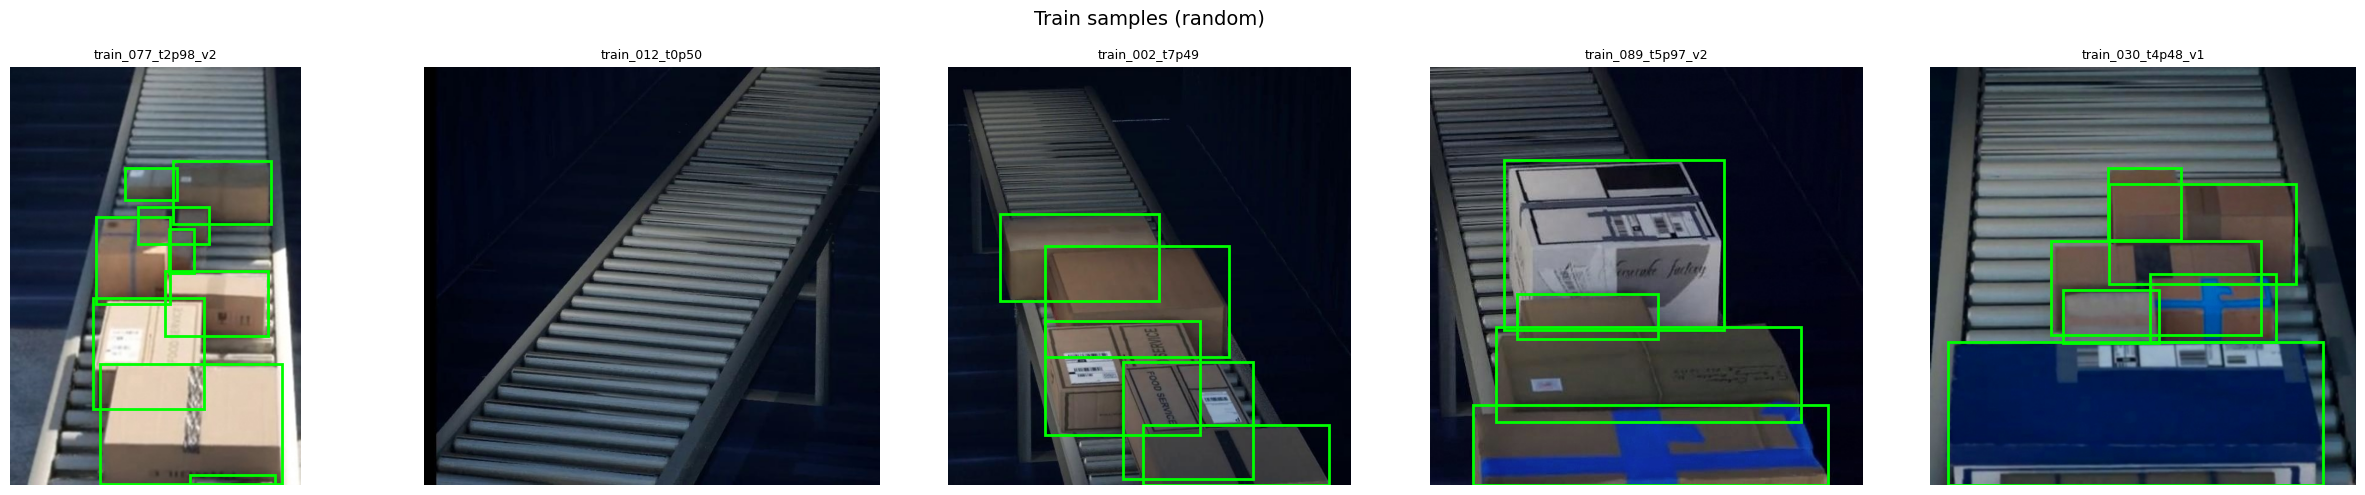

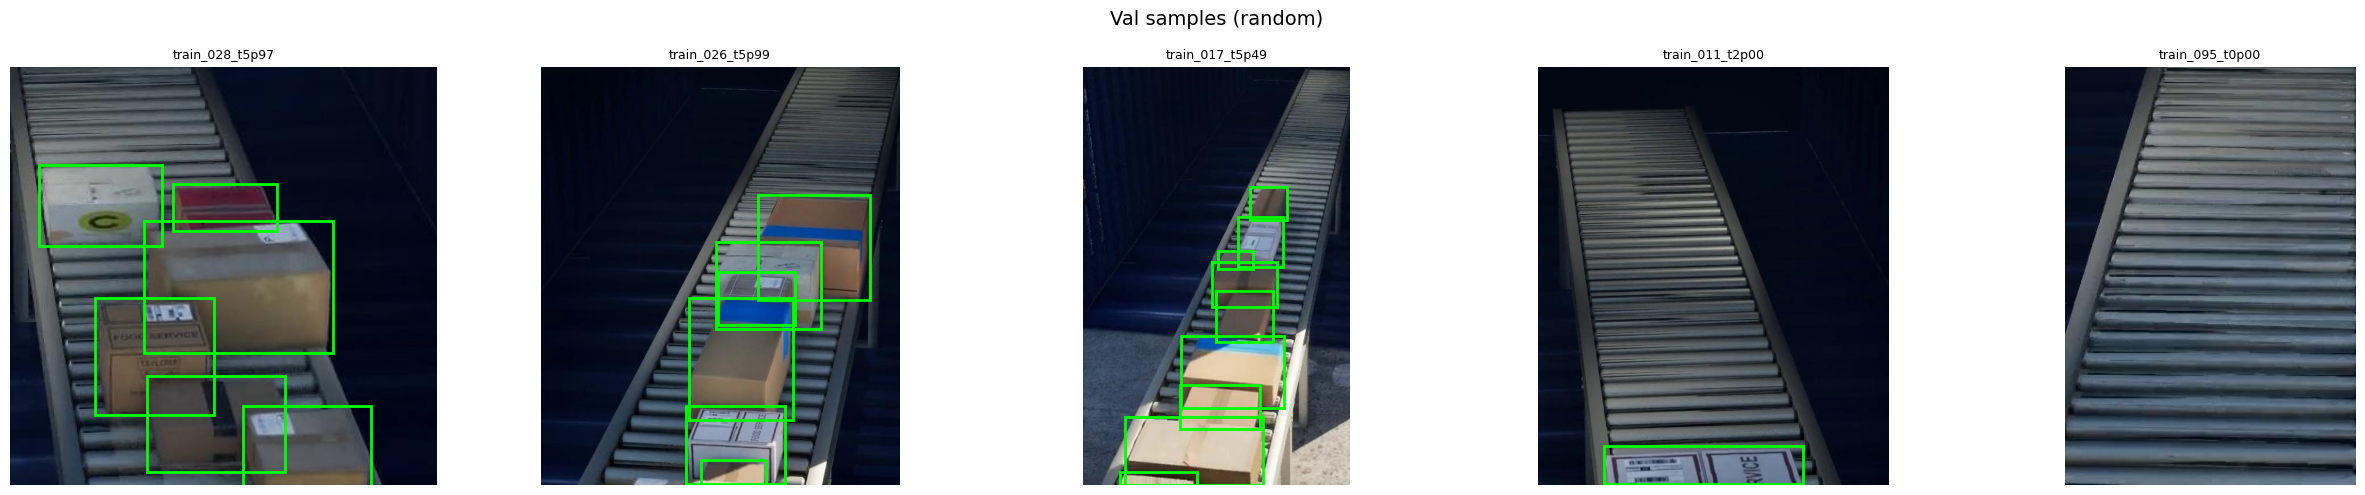

In [12]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import random

# ============================================================
# 설정
# ============================================================
SEED = 42
N_SAMPLES = 5

random.seed(SEED)


def draw_samples(image_dir, label_dir, n_samples, title_prefix):
    fnames = sorted(f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    if len(fnames) == 0:
        print(f"⚠️ {image_dir} 에 이미지가 없습니다.")
        return

    n_samples = min(n_samples, len(fnames))
    sampled = random.sample(fnames, n_samples)

    fig, axes = plt.subplots(1, n_samples, figsize=(5 * n_samples, 5))
    if n_samples == 1:
        axes = [axes]

    for ax, fname in zip(axes, sampled):
        base = os.path.splitext(fname)[0]
        img_path = os.path.join(image_dir, fname)
        txt_path = os.path.join(label_dir, base + ".txt")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        ax.imshow(img)

        if os.path.exists(txt_path):
            with open(txt_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id, xc, yc, bw, bh = parts
                    xc, yc, bw, bh = map(float, (xc, yc, bw, bh))

                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h

                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor="lime", facecolor="none"
                    )
                    ax.add_patch(rect)

        ax.set_title(base, fontsize=9)
        ax.axis("off")

    fig.suptitle(title_prefix, fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# Train / Val 각각 랜덤 5장 시각화
# ============================================================
draw_samples(OUT_TRAIN_IMAGE_DIR, OUT_TRAIN_LABEL_DIR, N_SAMPLES, "Train samples (random)")
draw_samples(OUT_VAL_IMAGE_DIR, OUT_VAL_LABEL_DIR, N_SAMPLES, "Val samples (random)")

# Yolo26 (Box Detection) Fine Tuning

In [13]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.9 MB/s eta 0:00:00


In [14]:
import random
import numpy as np
import os, yaml, torch
from ultralytics import YOLO

print(f"torch     : {torch.__version__}")
print(f"CUDA 사용 : {torch.cuda.is_available()}")
print(f"GPU       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch     : 2.11.0+cu128
CUDA 사용 : True
GPU       : NVIDIA A100-SXM4-80GB


In [15]:
# ==============================================================================
# 경로 설정
# ==============================================================================
DATASET_DIR   = '/content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented'
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, 'train', 'images')
TRAIN_LBL_DIR = os.path.join(DATASET_DIR, 'train', 'labels')
VAL_IMG_DIR   = os.path.join(DATASET_DIR, 'val', 'images')
VAL_LBL_DIR   = os.path.join(DATASET_DIR, 'val', 'labels')

CKPT_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing/checkpoints'
RUN_DIR  = '/content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs'
DATA_YAML = os.path.join(DATASET_DIR, 'data.yaml')

for d in [CKPT_DIR, RUN_DIR]:
    os.makedirs(d, exist_ok=True)

assert os.path.isdir(TRAIN_IMG_DIR), f"train images 없음: {TRAIN_IMG_DIR}"
assert os.path.isdir(VAL_IMG_DIR), f"val images 없음: {VAL_IMG_DIR}"

print(f"Train images : {len(os.listdir(TRAIN_IMG_DIR))}장")
print(f"Val images   : {len(os.listdir(VAL_IMG_DIR))}장")

Train images : 6492장
Val images   : 180장


In [ ]:
# ==============================================================================
# 1. data.yaml 생성
# ==============================================================================
# classes.txt에서 클래스 이름 로드
CLASSES_TXT = '/content/drive/MyDrive/CONTEST/cj_box_sizing/LabelStudioDataset/box/classes.txt'

with open(CLASSES_TXT, 'r') as f:
    class_names = [line.strip() for line in f if line.strip()]

print(f"클래스 목록 : {class_names}")

data_cfg = {
    'path': DATASET_DIR,
    'train': TRAIN_IMG_DIR,
    'val': VAL_IMG_DIR,
    'nc': len(class_names),
    'names': class_names,
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_cfg, f, allow_unicode=True)

print("\n[data.yaml]")
with open(DATA_YAML, 'r') as f:
    print(f.read())


# ==============================================================================
# 2. GPU 확인 및 batch 자동 설정
# ==============================================================================
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {vram_gb:.1f} GB")

if vram_gb >= 35:
    BATCH = 32    # A100 40G
elif vram_gb >= 20:
    BATCH = 16    # L4 / V100
else:
    BATCH = 8     # T4
print(f"Batch size : {BATCH}")

클래스 목록 : ['0']

[data.yaml]
names:
- '0'
nc: 1
path: /content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented
train: /content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented/train/images
val: /content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented/val/images

GPU  : NVIDIA A100-SXM4-80GB
VRAM : 85.1 GB
Batch size : 32


In [ ]:
# ==============================================================================
# 3. 모델 로드
# ==============================================================================
model = YOLO('yolo26l.pt')   # YOLO26-Large
print("\nModel loaded")
model.info()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


Model loaded
YOLO26l summary: 392 layers, 26,299,704 parameters, 0 gradients, 93.8 GFLOPs


In [ ]:
# ==============================================================================
# Fine-tuning (기존 augmentation 설정 그대로 유지)
# ==============================================================================
import random
import numpy as np

results = model.train(
    seed            = 42,
    data            = DATA_YAML,
    imgsz           = 640,

    epochs          = 100,
    batch           = BATCH,
    device          = 0,
    workers         = 4,
    patience        = 15,

    optimizer       = 'AdamW',
    lr0             = 0.001,
    lrf             = 0.01,
    momentum        = 0.9,
    weight_decay    = 1e-4,
    warmup_epochs   = 1.0,
    warmup_momentum = 0.8,
    warmup_bias_lr  = 0.01,

    box             = 5.0,
    cls             = 0.5,

    # ── Augmentation  ──
    fliplr          = 0.0,
    flipud          = 0.0,
    degrees         = 0.0,
    scale           = 0.4,
    translate       = 0.15,
    mosaic          = 0.0,
    mixup           = 0.0,
    close_mosaic    = 10,
    hsv_h           = 0.015,
    hsv_s           = 0.4,
    hsv_v           = 0.4,

    save            = True,
    save_period     = 10,
    project         = RUN_DIR,
    name            = 'yolo26l_v6_manual_augmentation',

    plots           = True,
    verbose         = True,
)

print(f"\nBest : {results.save_dir}/weights/best.pt")
print(f"Last : {results.save_dir}/weights/last.pt")

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=5.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l.pt, momentum=0.9, mosaic=0.0, multi_scale=0.0, name=yolo26l_v6

Total epochs  : 78
Best epoch    : 64
Best mAP50    : 0.9942
비율           : 0.82


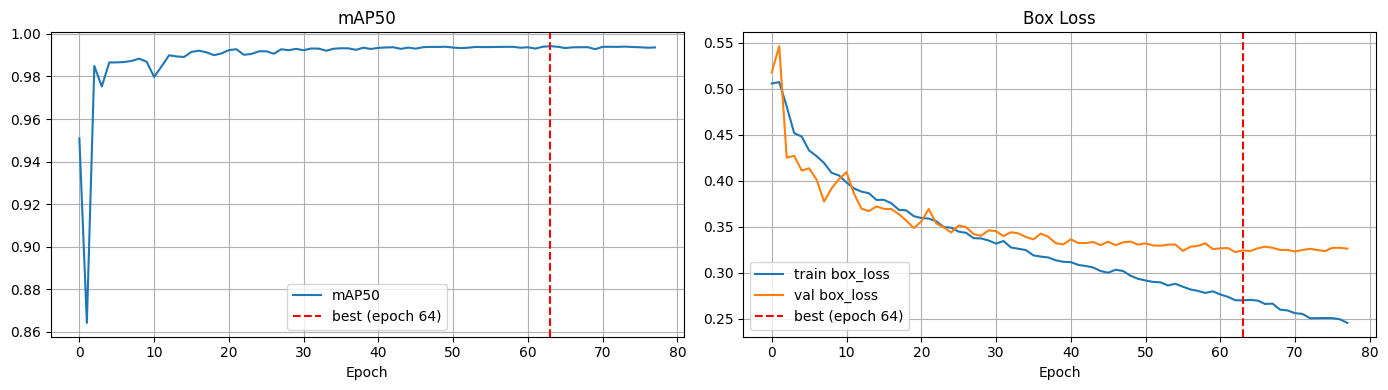

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# results.csv 경로
csv_path = f"{RUN_DIR}/yolo26l_v6_manual_augmentation/results.csv"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()  # 공백 제거

# best epoch 확인
best_epoch = df['metrics/mAP50(B)'].idxmax() + 1  # 0-indexed → 1-indexed
best_map50 = df['metrics/mAP50(B)'].max()
total_epochs = len(df)

print(f"Total epochs  : {total_epochs}")
print(f"Best epoch    : {best_epoch}")
print(f"Best mAP50    : {best_map50:.4f}")
print(f"비율           : {best_epoch/total_epochs:.2f}")

# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# mAP50
axes[0].plot(df['metrics/mAP50(B)'], label='mAP50')
axes[0].axvline(x=best_epoch-1, color='r', linestyle='--', label=f'best (epoch {best_epoch})')
axes[0].set_title('mAP50')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# val loss
if 'val/box_loss' in df.columns:
    axes[1].plot(df['train/box_loss'], label='train box_loss')
    axes[1].plot(df['val/box_loss'],   label='val box_loss')
    axes[1].axvline(x=best_epoch-1, color='r', linestyle='--', label=f'best (epoch {best_epoch})')
    axes[1].set_title('Box Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

plt.tight_layout()
plt.show()

# ONNX Export

In [17]:
!pip install onnxruntime-gpu==1.20.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.3 MB/s eta 0:00:00


In [18]:
from ultralytics import YOLO
import os, shutil, glob, random, math
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ==============================================================================
# YOLO26-L best.pt → ONNX 변환 및 Drive 저장 (v6_manual_augmentation)
# ==============================================================================
from ultralytics import YOLO
import os, shutil, glob, random, math
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 경로 설정
BEST_PT        = f"{RUN_DIR}/yolo26l_v6_manual_augmentation/weights/best.pt"
ONNX_DIR       = '/content/drive/MyDrive/CONTEST/cj_box_sizing/checkpoints'
ONNX_NAME      = 'yolo26l_v6_manual_augmentation.onnx'
ONNX_PATH      = os.path.join(ONNX_DIR, ONNX_NAME)
TEST_VIDEO_DIR = '/content/drive/MyDrive/CONTEST/cj_box_sizing/assignment1/dataset/test'
WORK_DIR       = '/content/work'

os.makedirs(ONNX_DIR, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

# ==============================================================================
# ONNX 변환
# ==============================================================================
print("🔄 ONNX 변환 중...")
model = YOLO(BEST_PT)

model.export(
    format   = 'onnx',
    imgsz    = 640,
    opset    = 17,
    simplify = True,
    dynamic  = False,
    half     = False,
)

local_onnx = BEST_PT.replace('.pt', '.onnx')
print(f"✅ ONNX 변환 완료: {local_onnx}")

# Drive로 복사
print(f"\n📂 Drive로 복사 중...")
shutil.copy(local_onnx, ONNX_PATH)
size_mb = os.path.getsize(ONNX_PATH) / 1e6
print(f"✅ Drive 저장 완료: {ONNX_PATH}  ({size_mb:.1f} MB)")

🔄 ONNX 변환 중...
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26l summary (fused): 190 layers, 24,746,511 parameters, 0 gradients, 86.1 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs/yolo26l_v6_manual_augmentation/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (50.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 194ms
Prepared 3 packages in 1.28s
Installed 3 packages in 251ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 2.3s
WARNING ⚠️ requirements:

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 6.2s, saved as '/content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs/yolo26l_v6_manual_augmentation/weights/best.onnx' (94.8 MB)

Export complete (7.4s)
Results saved to /content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs/yolo26l_v6_manual_augmentation/weights/best.onnx
Predict:         yolo predict task=detect model=/content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs/yolo26l_v6_manual_augmentation/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs/yolo26l_v6_manual_augmentation/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/CONTEST/cj_box_sizing/YOLO26_Label_Studio_Image_Augmented/data.yaml  
Visualize:       https://netron.app
✅ ONNX 변환 완료: /content/drive/MyDrive/CONTEST/cj_box_sizing/yolo26_runs/yolo26l_v6_manual_augmentation/weights/best.onnx

📂 Drive로 복사 중...
✅ Drive 저장 완료: /content/drive/MyDrive/CONTEST/cj_box_sizing/c

# 대회 제출용 requirements.txt 생성

In [19]:
# ==============================================================================
# requirements.txt 생성 (전체 pip freeze)
# ==============================================================================
import subprocess

req_path = "/content/drive/MyDrive/CONTEST/cj_box_sizing/requirements_box_detector.txt"

result = subprocess.run(["pip", "freeze"], capture_output=True, text=True)

with open(req_path, "w") as f:
    f.write(result.stdout)

print(f"총 {len(result.stdout.splitlines())}개 패키지 저장 완료: {req_path}")
print("\n--- 미리보기 (상위 20줄) ---")
print("\n".join(result.stdout.splitlines()[:20]))

총 711개 패키지 저장 완료: /content/drive/MyDrive/CONTEST/cj_box_sizing/requirements_box_detector.txt

--- 미리보기 (상위 20줄) ---
absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==25.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.14.0
anywidget==0.9.21
apsw==3.53.2.0
